In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
# import os

# load_dotenv(dotenv_path=".env", override=True)

# print(os.getenv("GROQ_API_KEY"))

load_dotenv()

True

In [11]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    
)

In [4]:
# Create State
class LLMState(TypedDict):
    question : str
    answer : str

In [5]:
def LLM_Quest(state: LLMState) -> LLMState:
    
    # extract the question from state
    question = state['question']

    # Form a prompt
    prompt = f'Answer the following question {question}'

    # ask the question to LLM
    answer=llm.invoke(prompt).content

    # Update the answer
    state['answer'] = answer

    return state

In [6]:
# Create graph
graph = StateGraph(LLMState)

# ADD nodes to the graph
graph.add_node('LLM_Quest', LLM_Quest)

# Add Edges in the graph
graph.add_edge(START,'LLM_Quest')
graph.add_edge('LLM_Quest',END)

# Compile the graph 
workflow = graph.compile()

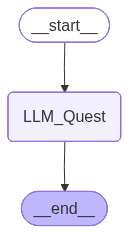

In [7]:
# Visualize the graph 
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [12]:
# Execute the workflow
initial_state = {'question':'what is agentic AI?'}
final_state = workflow.invoke(initial_state)
print(final_state)

{'question': 'what is agentic AI?', 'answer': 'Agentic AI refers to a type of artificial intelligence (AI) that exhibits behavior and characteristics similar to those of an intelligent agent. An intelligent agent is a system that can perceive its environment, set goals, take actions to achieve those goals, and adapt to changing circumstances.\n\nIn the context of AI, an agentic AI system is designed to be proactive, flexible, and goal-oriented. It can initiate actions and make decisions without being explicitly programmed to do so. Agentic AI systems are often characterized by the following properties:\n\n1. **Autonomy**: Agentic AI systems can act independently and make decisions without human intervention.\n2. **Reactivity**: They can respond to their environment and adapt to changing circumstances.\n3. **Proactivity**: They can initiate actions and make decisions to achieve their goals.\n4. **Self-awareness**: Agentic AI systems may have some degree of self-awareness, allowing them 